### This script evaluates strctural differences in brain age explanations between patients and matched controls.
Given precomputed explanations, a set of patients, and a set of matched controls this script generates effect size maps (masked by FWE-corrected significance) describing group differences.

In [9]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import json
import numpy as np
import pickle
from nilearn.mass_univariate import permuted_ols
from nilearn.plotting import plot_stat_map, show
from helper_methods import get_regressors_and_masked_expls_faster, cohen_d, get_mni_bg_img, get_T2_bg_img_controls

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Setup variables:

In [10]:
# for explanation posprocessing
clip_percentile = 99
fwhm = 4
scale_percentile = 99 # 90, 99
sign = "pos" # pos, abs

# which disease to evaluate
dis_codes = ["G35_t2"] # G35_t2 = MS

# which XAI methods to evaluate
xai_methods = ["SmoothGrad", "DeepLift_mean_img", "InputXGradient", "LRP_EpsilonAlpha2Beta1", "GradCAM", "GuidedBackprop"]

# we trained models with different seeds, so we evaluate the effect sizes for each seed
seed_ids = [2] # [2, 3] 

# path to precomputed explanations
result_dir = "/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/results/explanations/norm_bug_fixed/brain_age_disease_diff/T2_models"

Path to files:

In [ ]:
masker_path = "/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/brain-xai-benchmark/files/brain_masker/10k_brain_masker.pkl"
matching_file_path = "/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/model_training/training_file_generation/brain_age_disease_diff/ukb.matching_tjade.json"
split_dis_eids_path = "/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/model_training/training_files/brain_age_disease_diff/used_disease_as_test_split_T2.json"
split_control_eids_path = "/sc-projects/sc-proj-cc15-cn-ukbiobank/analyses/Explanation-benchmark-paper/model_training/training_files/T2_flair/split_matched_controls_T2.json"
ukb_table_path = "/sc-resources/ukb/data/projects/33073/ukb_data/table/ukb.parquet"


Load required files:

In [12]:
with open(masker_path, 'rb') as file:
    nifti_masker = pickle.load(file)

# size of masked explanations
mask_size = nifti_masker.n_elements_

# load matching file
with open(matching_file_path, 'r') as file:
    matching_file = json.load(file)


with open(split_dis_eids_path, 'r') as file:    
    dis_json = json.load(file)

dis_eids_T2 = dis_json["test"]

with open(split_control_eids_path, 'r') as file:
    control_json = json.load(file)

control_eids_T2 = control_json["test"]

# load age and sex field from UKBB
columns = ["f.eid", "f.31.0.0", "f.21003.2.0"]
ukbb_df = pd.read_parquet(ukb_table_path, columns=columns)

In [13]:
# get mean T2 image for healthy controls, later used as background image for plotting
T2_bg_img = get_T2_bg_img_controls(mask_size, nifti_masker)

SmoothGrad


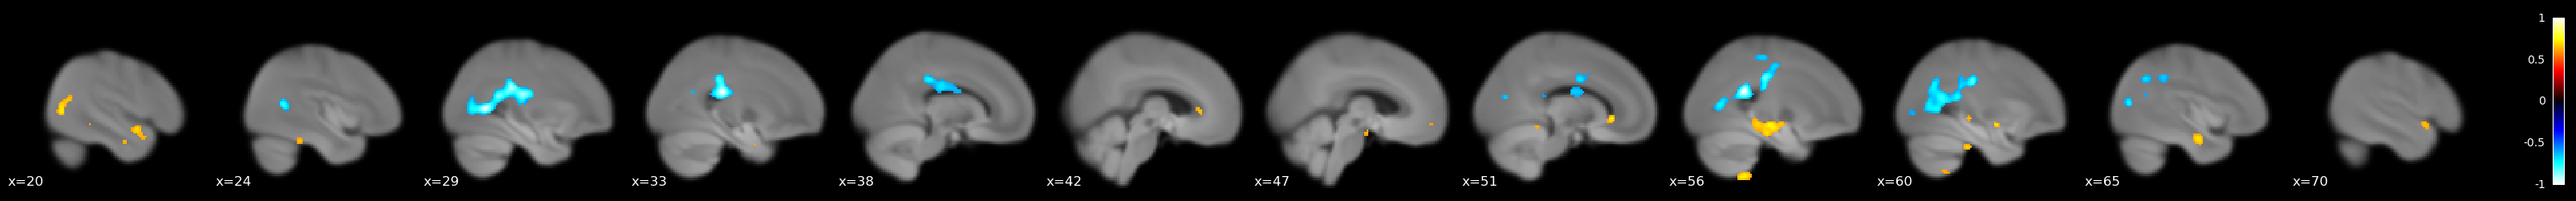

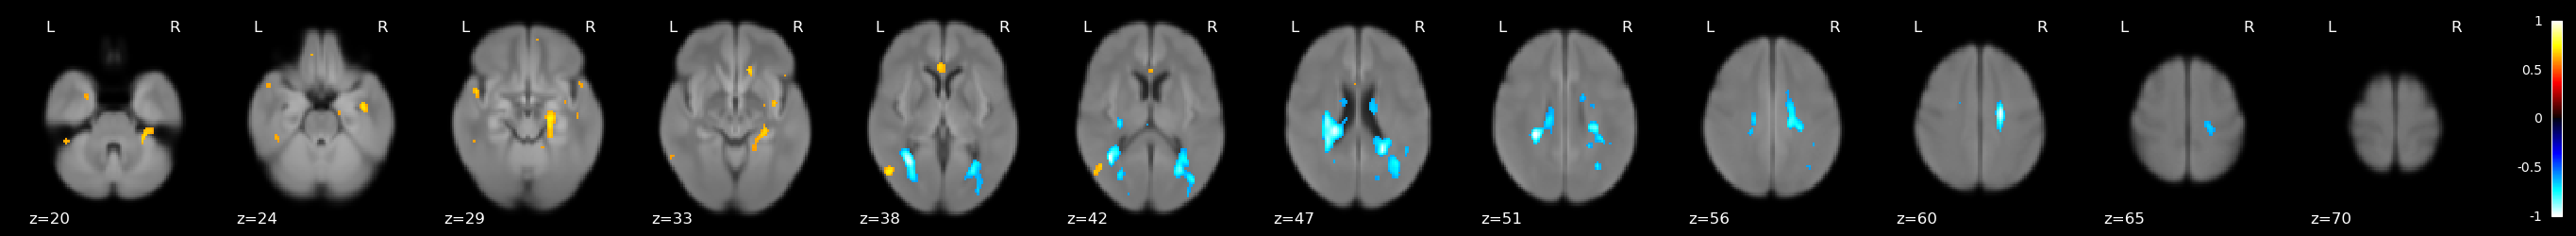

DeepLift


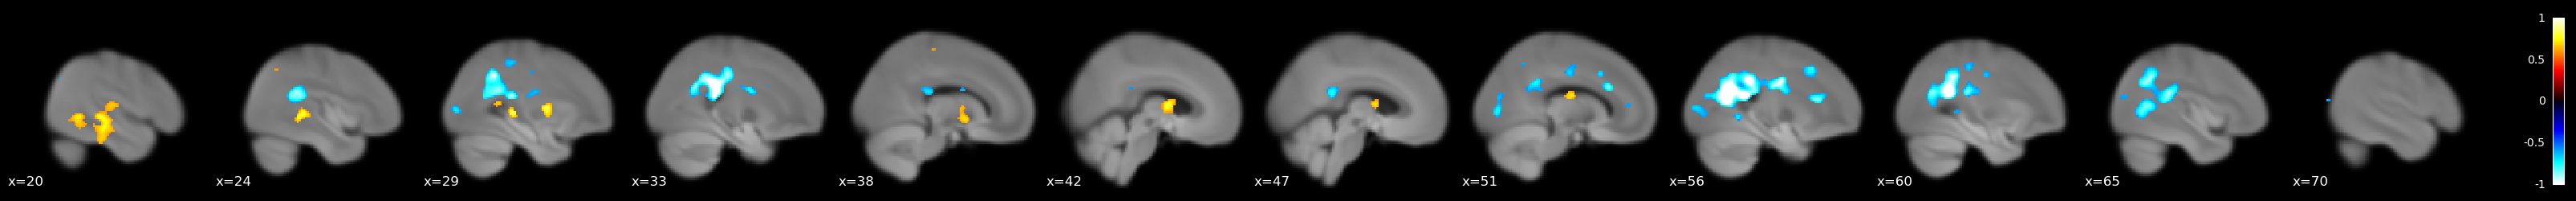

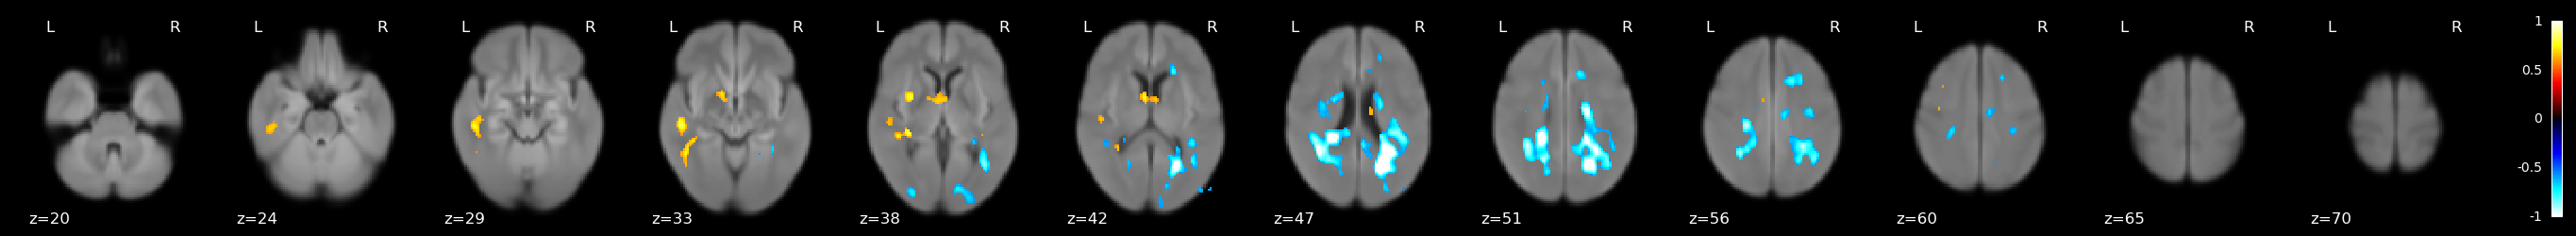

InputXGradient


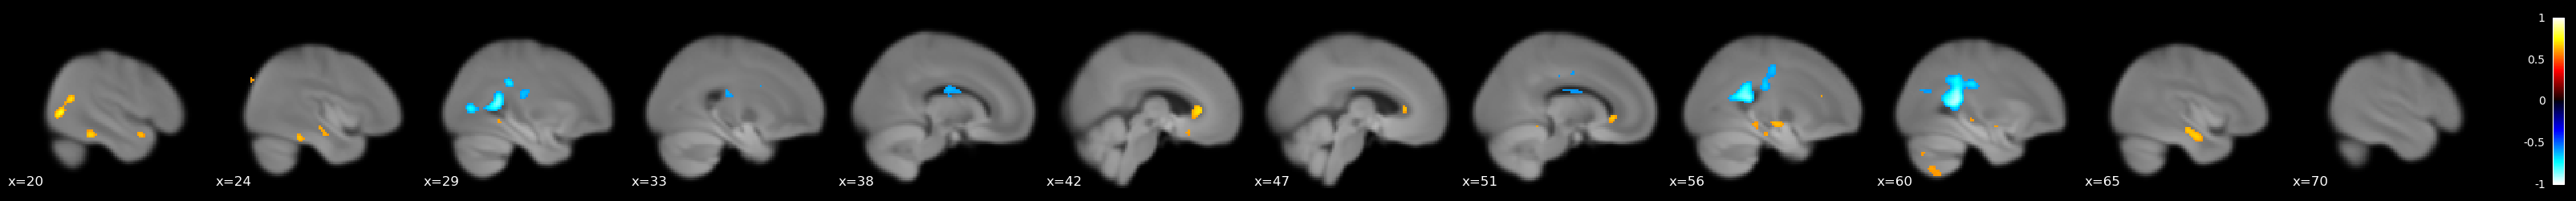

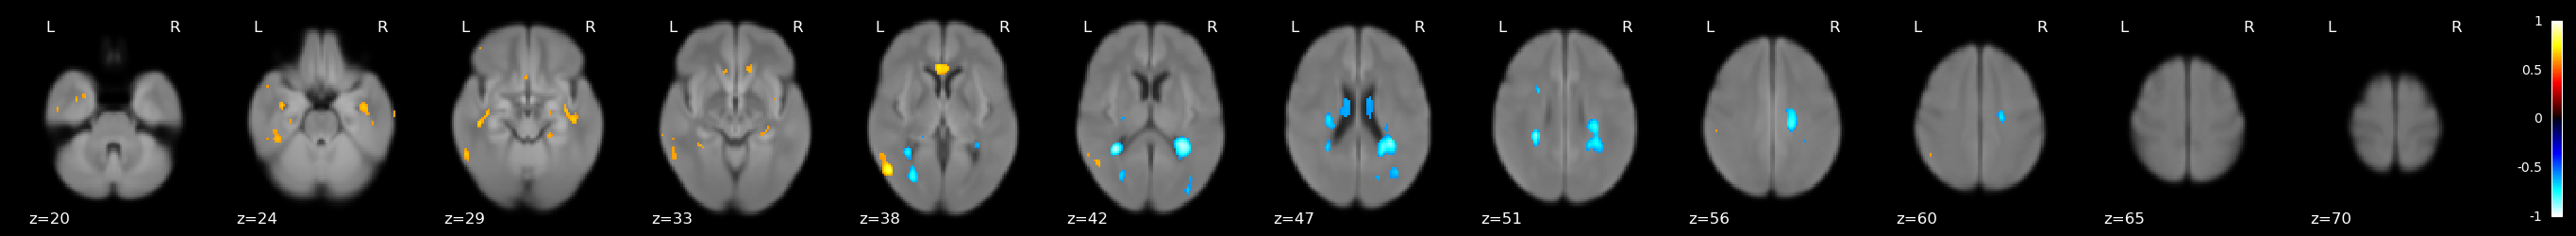

LRP_EpsilonAlpha2Beta1


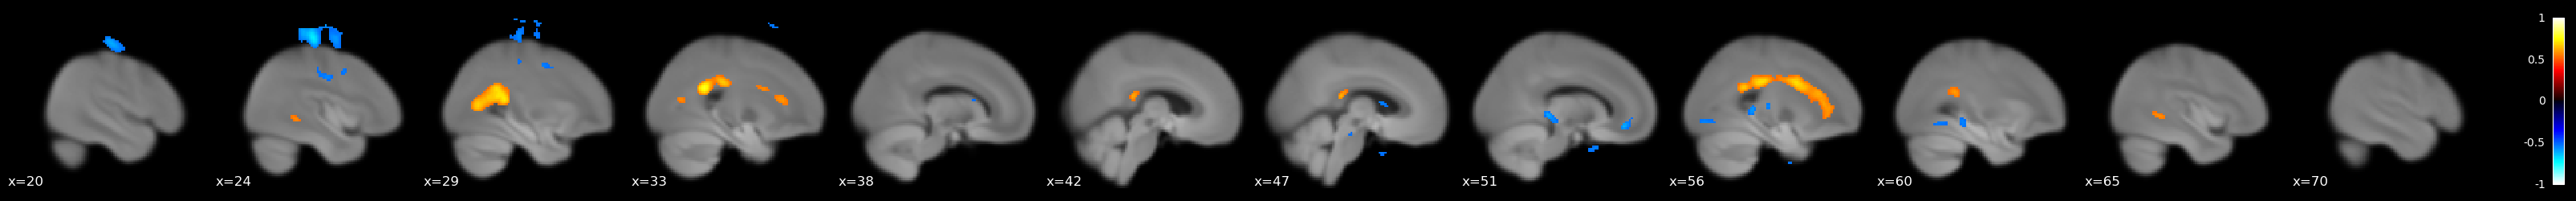

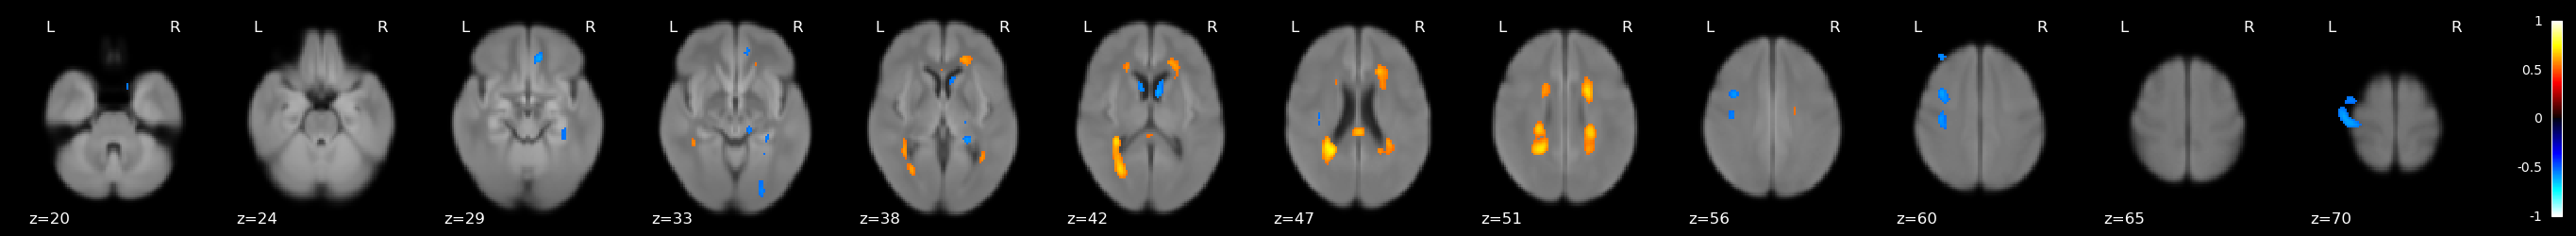

GradCAM


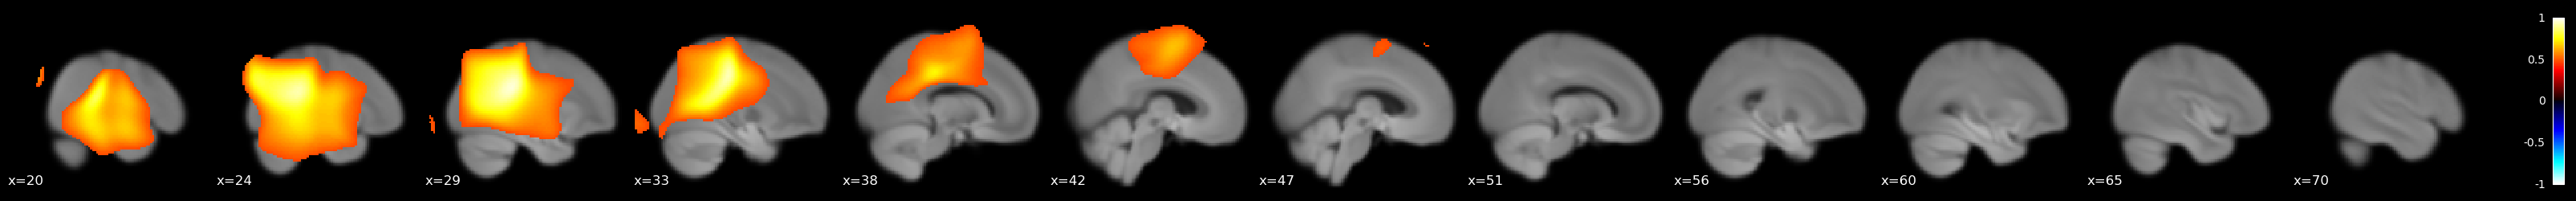

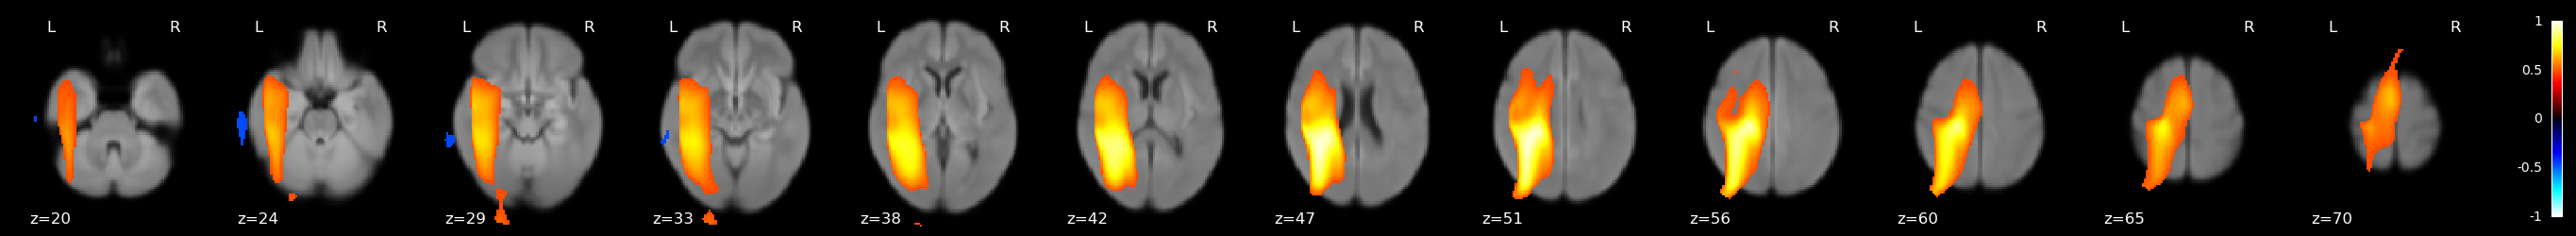

GuidedBackprop


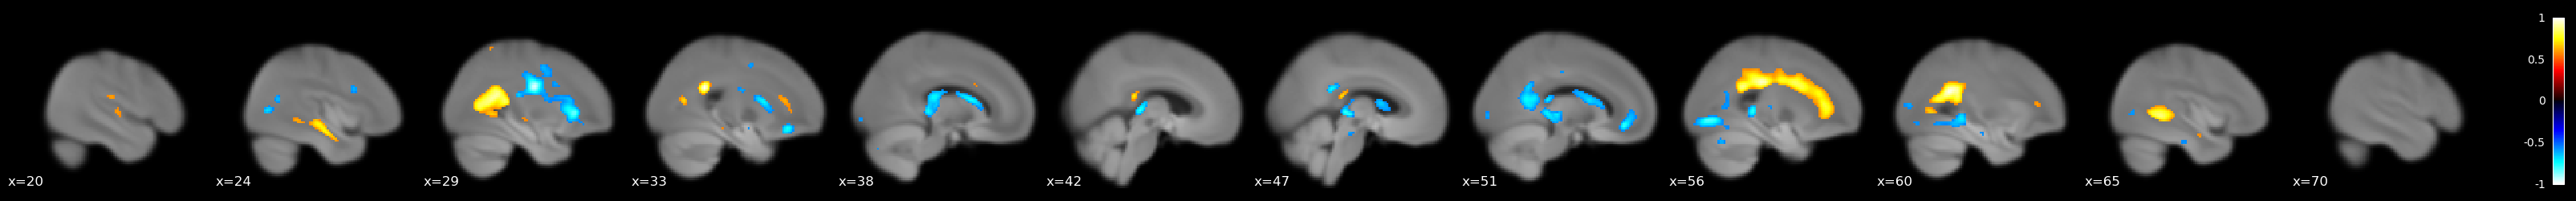

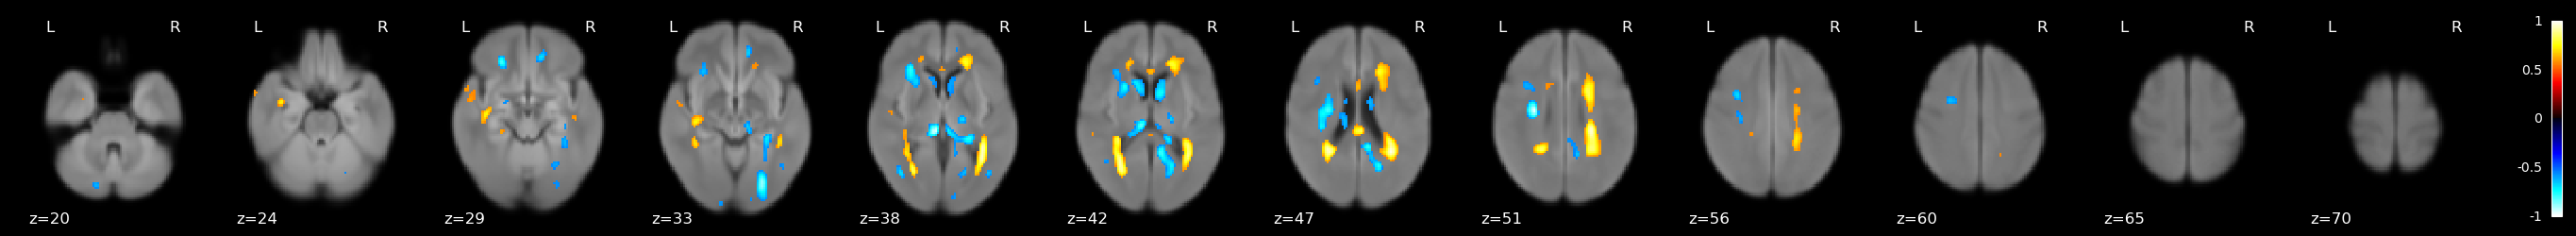

In [14]:
print_info=False

for dis in dis_codes:  
    if print_info: print(f"\n{dis}\n")

    for xai_m in xai_methods:
        
        # simjplify naming for plots
        if xai_m != "DeepLift_mean_img":
            print(xai_m)
        else:
            print("DeepLift")

        current_dis_eids = matching_file[dis]["eids_dx"]
        current_control_eids = matching_file[dis]["eids_cn"]

        current_dis_eids = [x for x in current_dis_eids if x in dis_eids_T2]
        current_control_eids = [x for x in current_control_eids if x in control_eids_T2]


        for seed in seed_ids:
            if print_info: print(f"seed: {seed}\n")
            
            # load predictions, explanations and eids
            predictions_controls = np.load(f'{result_dir}/seed_{seed}/control/predictions.npy')
            eids_controls = np.load(f'{result_dir}/seed_{seed}/control/prediction_eids.npy')

            predictions_dis = np.load(f'{result_dir}/seed_{seed}/disease/predictions.npy')
            eids_dis = np.load(f'{result_dir}/seed_{seed}/disease/prediction_eids.npy')

            control_prediction_df = pd.DataFrame({"f.eid":eids_controls, 'predictions':predictions_controls})
            dis_prediction_df = pd.DataFrame({"f.eid":eids_dis, 'predictions':predictions_dis})
                                    
            pred_df = pd.concat([control_prediction_df, dis_prediction_df], ignore_index=True)

            ukbb_df['f.eid']=ukbb_df['f.eid'].astype(int)

            ukbb_df_ = ukbb_df.merge(pred_df, on='f.eid')

            with open(f"{result_dir}/seed_{seed}/control/{xai_m}/masked_expls.npy", "rb") as file:
                control_expls = np.load(file)

            with open(f"{result_dir}/seed_{seed}/control/{xai_m}/eids.npy", "rb") as file:
                control_eids = np.load(file)
            
            with open(f"{result_dir}/seed_{seed}/disease/{xai_m}/masked_expls.npy", "rb") as file:
                dis_expls = np.load(file)

            with open(f"{result_dir}/seed_{seed}/disease/{xai_m}/eids.npy", "rb") as file:
                dis_eids = np.load(file)

            n_dis = len(current_dis_eids)

            # prepare inputs for nilearn mass univariate analysis
            masked_xpls_imgs, regressors = get_regressors_and_masked_expls_faster(n_dis, mask_size, current_dis_eids, current_control_eids, ukbb_df_, dis_eids, dis_expls, control_eids, control_expls, nifti_masker,
                                                                                            fwhm, scale_percentile, clip_percentile, sign)

            intercept = np.ones((len(current_dis_eids)+len(current_control_eids), 1))

            if not print_info:
                import warnings
                warnings.filterwarnings("ignore")

            # run nilearn mass univariate analysis for masking for masking the effect size maps later
            neg_log_pvals, t_scores, _ = permuted_ols(
            regressors,
            masked_xpls_imgs,
            confounding_vars=intercept,
            model_intercept=True,
            n_perm=200,
            verbose=0,
            n_jobs=8)

            signed_neg_log_pvals = neg_log_pvals[0,:]*np.sign(t_scores[0,:])

            # get effect sizes
            dis_expls = masked_xpls_imgs[regressors[:,0] == 1, :]
            control_expls = masked_xpls_imgs[regressors[:,0] == 0, :]

            effect_sizes = cohen_d(dis_expls, control_expls)

            # mask effect sizes
            effect_sizes[np.abs(signed_neg_log_pvals)<1.3] = 0

            if print_info:

                pos = sum(np.abs(effect_sizes[effect_sizes > 0]))
                neg = sum(np.abs(effect_sizes[effect_sizes < 0]))

                print(f"sum pos effect: {pos}")
                print(f"sum neg effect: {neg}")


            # plot results
            masked_effect_size_img = nifti_masker.inverse_transform(effect_sizes)
            
            for cut in ["x", "z"]:
                cut_coords = np.linspace(20, 70, num=12, dtype="int16")
                display = plot_stat_map(
                masked_effect_size_img,
                bg_img=T2_bg_img,
                display_mode=cut,
                threshold=0.0,
                cut_coords=cut_coords,      
                vmax = 1,
                )
            
                show()
       